In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:

%cd /content/drive/MyDrive/Manuscript_Segmentation/ManuscriptSegmentation/
%pip install -r requirements.txt
!pip install aspose-words

/content/drive/MyDrive/Manuscript_Segmentation/ManuscriptSegmentation


In [15]:
import unicodedata
import pandas as pd
import numpy as np

#1. Извлечение рукописи

In [16]:
# 1. Установка системной утилиты
!apt-get install -y antiword

import os
import re
import unicodedata

def get_raw_lines_from_doc(file_path):
    if not os.path.exists(file_path):
        print(f"Файл {file_path} не найден!")
        return []

    with os.popen(f'antiword "{file_path}"') as pipe:
        text = pipe.read()

    return text.splitlines()

text = get_raw_lines_from_doc('data/193-210.doc')

import re

def get_clean_words(raw_lines):
    # Паттерн: оставляем только нужные буквы, титла и разделитель-точку
    pattern = re.compile(r'[^а-яА-ЯёЁ\u0400-\u04FF\uA640-\uA69F\u0300-\u036F·\-\s]')

    full_text = []

    for line in raw_lines:
        line = re.sub(r'\d+[a-гв]?\s*', '', line).strip()
        # 1. Удаляем всё, что не входит в наш славянский паттерн (цифры пагинации и т.д.)
        line = pattern.sub('', line)
        # 2. Нормализуем пробелы
        line = ' '.join(line.split())
        if line:
            full_text.append(line)

    # Склеиваем всё в одну строку для обработки переносов
    combined_text = " ".join(full_text[1:])

    # 3. Обработка переносов: "же- нѹ" -> "женѹ"
    # Ищем дефис, за которым следуют пробелы и после часть слова
    combined_text = re.sub(r'-\s+', '', combined_text)
    print(combined_text[:100])

    # Очищаем от точек-разделителей, чтобы они не липли к словам в словаре
    words = [w.strip('·') for w in combined_text.split() if len(w.strip('·')) > 0]

    return words

words_corpus = get_clean_words(text)

print(f"Корпус собран. Всего слов: {len(words_corpus)}")
print("Первые 15 слов корпуса:")
print(words_corpus[:15])
#-----Пока не обрабатывает года, но обрабатывает номера страницу, буквы между рукописями

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
antiword is already the newest version (0.37-16).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.
безазорнъ҇хъ лиць кромѣ ходѧть · женѹ имать или рабъ҇нѧ · безазорьноѥ себе ѡ семь хранѧ · аще ли пре
Корпус собран. Всего слов: 4687
Первые 15 слов корпуса:
['безазорнъ҇хъ', 'лиць', 'кромѣ', 'ходѧть', 'женѹ', 'имать', 'или', 'рабъ҇нѧ', 'безазорьноѥ', 'себе', 'ѡ', 'семь', 'хранѧ', 'аще', 'ли']


#train_test_split



In [17]:
from os.path import split
from sklearn.model_selection import train_test_split

split_index_1 = int(len(words_corpus) * 0.7)
split_index_2 = int(len(words_corpus) * 0.8)
train_text = words_corpus[:split_index_1] + words_corpus[split_index_2:]
test_text = words_corpus[split_index_1:split_index_2]
words_corpus = train_text

In [18]:
#stemmer  = nltk.SnowballStemmer('russian')
#words_corpus = [stemmer.stem(segment) for segment in words_corpus]

#]==%%time
#snlp = stanza.Pipeline(lang="ru")
#nlp = StanzaLanguage(snlp)

# Разбиваем на два куска, так как максимальная длина входа 1000000 символов
#gap = len(nltk_tokenized_text) // 2
#subtext1 = ' '.join(nltk_tokenized_text[:gap])
#subtext2 = ' '.join(nltk_tokenized_text[gap:])

#doc1 = nlp(subtext1)
#doc2 = nlp(subtext2)

#lemm_text = [token.lemma_ for token in doc1] + [token.lemma_ for token in doc2]


#------- Можно обучать на изменённом lemmit_words_corpusl, а при процессе сегментации проверять lemmited слово из чистого words_corpus

# 2. (Counter) Статистика по словам

In [19]:
from typing import Counter
import nltk, re
from collections import Counter
from nltk.corpus import stopwords

counter = Counter(words_corpus)
df = pd.DataFrame(data = counter.items(), columns = ['Word', 'Count']).sort_values('Count', ascending = False)
df['Word'] = df['Word'].apply(lambda x: x.lower())

# пока что будем брать stopwords тк они могут содержаться в отдельных словах, что может неправильно сегментриовать текст
nltk.download('stopwords')
stop_words =stopwords.words('russian')
df = df[~df['Word'].isin(stop_words)]
sum_unigram_counts = df['Count'].sum() # Нужно будет в алгоритме для нормировки score_word

df

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Word,Count
60,въ,109
13,аще,71
61,ѿ,60
90,ӻко,35
228,бѹдеть,32
...,...,...
829,дондеже,1
828,възъвратитисѧ,1
825,варварьску,1
824,нахожению,1


# Будем состовлять такде биграммы, и находить условную вероятность встречи пары слов в тексте в текущей позиции (для дальнейшего предсказания наличия пробела)
# (слово1б слово2) = (w1, w2)
#  Найдём также условную вероятность птого, что (w2 = couple_words[1]), ghb том что (w1 = couple_words[0]), P(w2|w1) = P(w1 * w2) / P(w1)

# 3. Униграммы, Биграммы

в алгоритме вроде как находим условную вероятность, так что в методе биграммы, это можно убрать

In [20]:
# Counter для биграмм, для двух слов рядом
counter_twice = Counter(zip(words_corpus, words_corpus[1:]))
df_twice = pd.DataFrame(data = counter_twice.items(), columns = ['Word', 'Count']) #.sort_values('Count', ascending = False)
df_twice['Word'] = df_twice['Word'].apply(lambda x: ' '.join(x)).str.lower()
df_twice.sort_values('Count', ascending = False, inplace = True)

vocab_words = set(df['Word'].str.lower()) # будем обходить стороной отсутсвующие слова в корпусе слов в алогритме

df_unigrams = set(df['Word'].values)
df_bigrams = set(df_twice['Word'].values)

def unigram_prob(word: str, alpha = 0.01):
    word = word.lower()
    if word not in df_unigrams:
        return 0
    # Возвращает СЫРОЙ каунт слова, а не дробь
    val = df[df['Word'] == word]['Count'].values[0]
    return val

def bigram_prob(couple_words, alpha = 0.01):
    w1, w2 = map(str.lower, couple_words)
    couple_words = w1 + ' ' + w2

    if w1 in df_unigrams and couple_words in df_bigrams:
        count_AB = df_twice[df_twice['Word'] == couple_words]['Count'].values[0]
        return count_AB # Возвращает сырой каунт биграммы
    else:
        if w2 in df_unigrams:
            return 0.4 * df[df['Word'] == w2]['Count'].values[0]
        else:
            return 0

print('Распределение частоты биграмм')

counts_of_bigram_counts = df_twice['Count'].value_counts()
counts_of_bigram_counts.name = 'count_of_bigrams_counts'
counts_of_bigram_counts



Распределение частоты биграмм


,count_of_bigrams_counts
Count,
1,3566
2,181
3,40
4,14
5,8
12,2
6,2
10,1
11,1


In [21]:
print('Биграммы')
df_twice

Биграммы


,Word,Count
13,аще ли,12
906,да не,12
250,и въ,11
21,се же,10
54,аще и,9
...,...,...
3806,ѹкрашенъ҇ многоцѣньно,1
3807,многоцѣньно къ,1
3808,къ ѡлтареви,1
3793,ѿ водѧщихъ,1


#4. алгоритм Витерби (марковские цепи), модифицированный под задачу сегментации

In [22]:
import math

def viterbi_segment(s, vocab_size, penalty_letter):
    n = len(s)
    dp = [float('-inf')] * (n + 1) # score , вероятность наилучшей сегментации (prev_word, word) c концом word на i индексe текста
    prev_idx = [-1] * (n + 1) # Наиболее вероятный индекс конца предыдущего сегмента для i
    last_word_at = [None] * (n + 1) # Храним само слово (наиболее вероятный сегмент с концом на этом индексе i)

    dp[0] = 0
    min_word_len = 1
    max_word_len = 15

    # Константы штрафов
    UNK_PENALTY = -20
    LOW_PROB_BIGRAM = math.log(1 / vocab_size) # если биграммы нет в словаре

    # нахождение первого слова
    def seek_first_word():
        best_prob, first_word = float('-inf'), None
        for i in range(1, min(max_word_len, n) + 1):
            # Переводим обычную вероятность в лог, для избежания зануления вероятности
            prob = math.log(unigram_prob(s[:i].lower()) / sum_unigram_counts) if unigram_prob(s[:i]) > 0 else UNK_PENALTY - penalty_letter *i
            if prob > best_prob:
                best_prob = prob
                first_word = s[:i]
        return first_word

    first_w = seek_first_word()
    start = len(first_w)

    dp[start] = math.log(unigram_prob(first_w)) if unigram_prob(first_w) > 0 else UNK_PENALTY - penalty+letter* start
    prev_idx[start] = 0
    last_word_at[start] = first_w

    # Алгоритм
    for i in range(start + 1, n + 1):
        best_score = float('-inf')
        best_j, best_word = -1, None

        for L in range(min_word_len, min(max_word_len, i) + 1):
            j = i - L
            # # Если до позиции j нельзя добраться valid-путем, пропускаем шаг
            if dp[j] == float('-inf'):
                continue

            word = s[j:i].lower()

  # 1. Unigram score (не только по паре слов предсказываем)
            raw_uni = unigram_prob(word)
            if raw_uni > 0:
                score_word = math.log(raw_uni / sum_unigram_counts) # нормировка
            else:
                # чем меньше длина L, тем штраф сильнее (защита от однобуквенных слов)
                score_word = UNK_PENALTY - penalty_letter * L
            # ---?? сменили знак , чтоб в total_score был правильный знак penalty

  # 2. Bigram score (Conditional score)
            try:
                prev_word = (last_word_at[j]).lower()
                couple_string = f"{prev_word} {word}"
            except (IndexError, AttributeError, TypeError):
              conditional_bigram_score = LOW_PROB_BIGRAM

            # p(B|A) = p(AB) / p(A)
            # МИНИМАЛЬНАЯ РЕГУЛЯРИЗАЦИЯ:
            if couple_string in df_bigrams:
                raw_AB = bigram_prob((prev_word, word))
                raw_A = unigram_prob(prev_word)
                if raw_AB > 0 and raw_A > 0:
                    conditional_bigram_score = math.log(raw_AB) - math.log(raw_A)
                else:
                    conditional_bigram_score = LOW_PROB_BIGRAM
            else:
                # Если биграммы нет — даем стабильный штраф регуляризации,
                # чтобы модель не переобучалась на тестовом контексте
                conditional_bigram_score = LOW_PROB_BIGRAM

  # conditional probability for couple at position j
  # 3. Score
            # накапливаем ранее найденные score d[j] для позиции j (те который находили для другого раннего слова)
            total_score = dp[j] + conditional_bigram_score + score_word # dp[j] вроде не надо тк мы его выч после выбоар слов для i

            if total_score > best_score:
                best_score = total_score
                best_j, best_word = j, s[j:i]

        if best_j != -1:
            dp[i] = best_score
            prev_idx[i] = best_j
            last_word_at[i] = best_word

    # Восстановление
    res = []
    curr = n
    while curr > start:
        current_start = prev_idx[curr]
        if current_start == -1:
            break
        res.append(s[current_start:curr])
        curr = current_start

    res.append(s[:start])
    return res[::-1]

In [23]:
str_words_corpus = ''.join(words_corpus)
#size = len(sorted(list(set(list(str_words_corpus)))))
vocab_size = len(df_bigrams)
viterbi_segment((str_words_corpus), vocab_size, 0.1)


['безазорнъ҇хъ',
 'лиць',
 'кромѣ',
 'ходѧть',
 'женѹ',
 'иматьилирабъ҇нѧ',
 'безазорьноѥ',
 'себеѡсемьхранѧ',
 'аще',
 'липрестѹпаѥтькт',
 'онамиповелѣнаӻд',
 'аизвержетьс̑сеж',
 'еископьцихранѧт',
 'ьнепорочноѥсебе',
 'промъ҇шлѧюще',
 'престѹпающе',
 'жеащепричетничи',
 'сѹтьдаизвергѹть',
 'сѧащелипростьчи',
 'даѿтъл̑лѹчатьсѧ',
 'Ижеимѣтирабъ҇нѧ',
 'илиинъ҇ӻженъ҇ѹс',
 'ебевдомѹсщнъ҇мъ',
 'рекше',
 'прозвѹтерѻмъ',
 'аще',
 'ископцисѹтьащеи',
 'зѣлосѹтьстаръ҇и',
 'се',
 'правило',
 'възбранѧѥть',
 'ивеликаговаси',
 'лиӻкъгригорью',
 'прозвѹтерѹ',
 'посланиѥ',
 'запрещаѥть',
 'томѹ',
 'бъ҇вати',
 'тъкмо',
 'ащектоиматьѹсеб',
 'евъдомѹженѹѿзаз',
 'орнъ҇хълицьвъни',
 'хъженѣс̑боӻзьни',
 'нипорокаӻкожесе',
 'мтрьилисестрѹил',
 'итеткѹпоѡциилип',
 'омтрирекшеѻцасв',
 'оѥгосестрѹилимт',
 'реилиинѹнѣкѹюѿ',
 'таковъ҇хъ',
 'преступающаӻ',
 'жеправиласи',
 'изъврещи',
 'повелѣваѥмъ',
 'наскопцажеболми',
 'исеправило',
 'наводить',
 'ӻко',
 'аще',
 'мирьстии',
 'члвчисѹтьиживѹт',
 'ьвдомѹсъчюжими

# 5. Подбор параметров

In [24]:
import difflib

def validate_on_matcher(words_corpus):
    f1_score, penalty = 0, 0
    penalty_letters = [0.1, 1, 10, 100, 1000] # Добавил промежуточных значений
    predicted, rows_summary = [], []

    real_text = ' '.join(words_corpus)

    for penalty_letter in penalty_letters:
        segmented_list = viterbi_segment(''.join(words_corpus), vocab_size, penalty_letter)
        segmented_text = ' '.join(segmented_list)

        # Используем SequenceMatcher для поиска совпадений границ (Ratio)
        matcher = difflib.SequenceMatcher(None, segmented_text, real_text)

        # Получаем точность посимвольного совпадения
        f1 = matcher.ratio()

        # Если f1 не растет, пробуем посмотреть, как он сегментирует
        print(f"Penalty {penalty_letter}: Accuracy = {f1:.4f}")
        rows_summary.append({
            'Penalty': penalty_letter,
            'F1-Score': f1, })

        if f1 > f1_score:
            f1_score = f1
            penalty = penalty_letter
            predicted = segmented_list

    rows_summary = pd.DataFrame(rows_summary)
    display(rows_summary.style.highlight_max(subset=['F1-Score'], color='lightgreen'))

    return f1_score, penalty, predicted

f1_score, penalty, predicted = validate_on_matcher(words_corpus)
print('\n')
print('Оптимальный параметр:\n')
print(f'Penalty:{penalty}, accuracy: {f1_score}')
print('\n')

Penalty 0.1: Accuracy = 0.7353
Penalty 1: Accuracy = 0.8480
Penalty 10: Accuracy = 0.9925
Penalty 100: Accuracy = 0.9708
Penalty 1000: Accuracy = 0.9708


,Penalty,F1-Score
0,0.100000,0.735291
1,1.000000,0.847964
2,10.000000,0.992468
3,100.000000,0.970802
4,1000.000000,0.970802




Оптимальный параметр:

Penalty:10, accuracy: 0.9924677788316688




In [25]:
list(zip(words_corpus, predicted))

[('безазорнъ҇хъ', 'безазорнъ҇хъ'),
 ('лиць', 'лиць'),
 ('кромѣ', 'кромѣ'),
 ('ходѧть', 'ходѧть'),
 ('женѹ', 'женѹ'),
 ('имать', 'имать'),
 ('или', 'или'),
 ('рабъ҇нѧ', 'рабъ҇нѧ'),
 ('безазорьноѥ', 'безазорьноѥ'),
 ('себе', 'се'),
 ('ѡ', 'беѡ'),
 ('семь', 'семь'),
 ('хранѧ', 'хранѧ'),
 ('аще', 'аще'),
 ('ли', 'ли'),
 ('престѹпаѥть', 'престѹпаѥть'),
 ('кто', 'кто'),
 ('нами', 'нами'),
 ('повелѣнаӻ', 'повелѣнаӻ'),
 ('да', 'да'),
 ('извержетьс̑', 'извержетьс̑'),
 ('се', 'се'),
 ('же', 'жеи'),
 ('и', 'скопьци'),
 ('скопьци', 'хранѧть'),
 ('хранѧть', 'непорочноѥ'),
 ('непорочноѥ', 'себе'),
 ('себе', 'промъ҇шлѧюще'),
 ('промъ҇шлѧюще', 'престѹпающе'),
 ('престѹпающе', 'же'),
 ('же', 'аще'),
 ('аще', 'причетничи'),
 ('причетничи', 'сѹть'),
 ('сѹть', 'да'),
 ('да', 'извергѹтьсѧ'),
 ('извергѹтьсѧ', 'аще'),
 ('аще', 'ли'),
 ('ли', 'простьчи'),
 ('простьчи', 'да'),
 ('да', 'ѿтъл̑'),
 ('ѿтъл̑', 'лѹчатьсѧ'),
 ('лѹчатьсѧ', 'Иже'),
 ('Иже', 'имѣти'),
 ('имѣти', 'рабъ҇нѧ'),
 ('рабъ҇нѧ', 'или'),
 ('или',

Penalty 0.1 : F1-Score = 0.5013 (P: 0.6866, R: 0.3947)
Penalty 1   : F1-Score = 0.6892 (P: 0.8340, R: 0.5872)
Penalty 7   : F1-Score = 0.9475 (P: 0.9653, R: 0.9303)
Penalty 9   : F1-Score = 0.9544 (P: 0.9658, R: 0.9433)
Penalty 10  : F1-Score = 0.9551 (P: 0.9649, R: 0.9455)
Penalty 15  : F1-Score = 0.9518 (P: 0.9589, R: 0.9448)
Penalty 20  : F1-Score = 0.9505 (P: 0.9559, R: 0.9452)
Penalty 50  : F1-Score = 0.9052 (P: 0.8889, R: 0.9220)
Penalty 100 : F1-Score = 0.9052 (P: 0.8889, R: 0.9220)


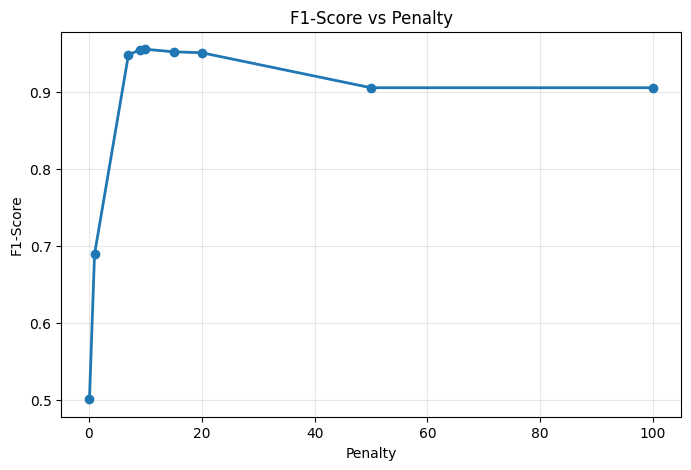


Лучший penalty = 10, F1 = 0.9550951981798587


In [26]:
import matplotlib.pyplot as plt
import pandas as pd

def validate_on_sets(words_corpus):
    f1_score = 0
    penalty = 0

    rows_summary = []

    # Сетка параметров для GridSearch
    penalty_letters = [0.1, 1, 7, 9, 10, 15, 20, 50, 100]

    # Строим эталонные слова (gold) — один раз, вне цикла
    gold_words = set()
    current_idx = 0
    for word in words_corpus:
        gold_words.add((current_idx, current_idx + len(word), word))
        current_idx += len(word)

    solid_text = ''.join(words_corpus)

    for penalty_letter in penalty_letters:
        # Сегментируем
        segmented_list = viterbi_segment(solid_text, vocab_size, penalty_letter)

        # Строим предсказанные слова (pred) — по индексам
        pred_words = set()
        current_idx = 0
        for word in segmented_list:
            pred_words.add((current_idx, current_idx + len(word), word))
            current_idx += len(word)

        # TP (пересечение множеств координат)
        tp = len(gold_words & pred_words)

        precision = tp / len(pred_words) if len(pred_words) > 0 else 0
        recall = tp / len(gold_words) if len(gold_words) > 0 else 0

        if precision + recall > 0:
            f1 = 2 * (precision * recall) / (precision + recall)
        else:
            f1 = 0

        print(f"Penalty {penalty_letter:<4}: F1-Score = {f1:.4f} (P: {precision:.4f}, R: {recall:.4f})")

        rows_summary.append({
            'Penalty': penalty_letter,
            'F1-Score': f1,
        })

        if f1 > f1_score:
            f1_score = f1
            penalty = penalty_letter

    rows_summary = pd.DataFrame(rows_summary)

    plt.figure(figsize=(8, 5))
    plt.plot(rows_summary['Penalty'], rows_summary['F1-Score'], marker='o', linewidth=2, markersize=6)
    plt.xlabel('Penalty')
    plt.ylabel('F1-Score')
    plt.title('F1-Score vs Penalty')
    plt.grid(True, alpha=0.3)
    plt.show()

    return f1_score, penalty

f1_score, penalty = validate_on_sets(words_corpus)
print(f"\nЛучший penalty = {penalty}, F1 = {f1_score}")

In [27]:
print("Наилучший штраф при подборе для метрики ошибки:", penalty)
print(f'f1_score = {f1_score}')

Наилучший штраф при подборе для метрики ошибки: 10
f1_score = 0.9550951981798587


#6.Тестировапние

In [28]:
import difflib

best_penalty = penalty
def test_on_sets(test_text, penalty_letter):
    test_text = ''.join(test_text)
    segmented_test_list = viterbi_segment(test_text, vocab_size, penalty_letter)
    segmented_test_text = ' '.join(segmented_test_list)

    # Используем SequenceMatcher для поиска совпадений границ (Ratio)
    matcher = difflib.SequenceMatcher(None, segmented_test_text, test_text)
    f1 = matcher.ratio()

    print(f" Accuracy = {f1:.4f}")
    return f1_score, predicted

f1_score, predicted = test_on_sets(test_text, best_penalty)
print('\n')

 Accuracy = 0.4314




In [29]:
def test_on_segments_idxs(test_text_corpus, penalty_letter):
    solid_test = ''.join(test_text_corpus)
    segmented_test_list = viterbi_segment(solid_test, vocab_size, penalty_letter)

    gold_words = set()
    current_idx = 0
    for word in test_text_corpus:
        gold_words.add((current_idx, current_idx + len(word), word))
        current_idx += len(word)

    pred_words = set()
    current_idx = 0
    for word in segmented_test_list:
        pred_words.add((current_idx, current_idx + len(word), word))
        current_idx += len(word)

    tp = len(gold_words & pred_words)

    precision = tp / len(pred_words) if len(pred_words) > 0 else 0
    recall = tp / len(gold_words) if len(gold_words) > 0 else 0

    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    print(f"Тестовый F1-Score = {f1:.4f}\n")
    print(f"Тестовый precision = {precision:.4f}\n")

    return f1, precision, segmented_test_list

# Запуск теста
test_f1, predicted_test, segmented_test_list = test_on_segments_idxs(test_text, best_penalty)

Тестовый F1-Score = 0.4089

Тестовый precision = 0.4085



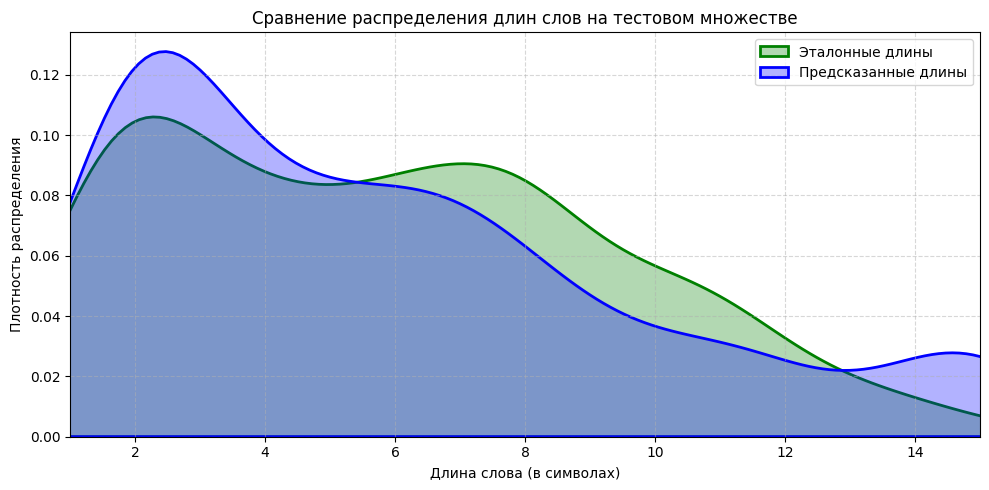

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Считаем длины реальных слов и предсказанных
gold_lens = [len(word) for word in test_text]
pred_lens = [len(word) for word in segmented_test_list]

plt.figure(figsize=(10, 5))
sns.kdeplot(gold_lens, label='Эталонные длины ', fill=True, color='green', alpha=0.3, linewidth=2)
sns.kdeplot(pred_lens, label='Предсказанные длины', fill=True, color='blue', alpha=0.3, linewidth=2)
plt.xlabel('Длина слова (в символах)')
plt.ylabel('Плотность распределения')
plt.title('Сравнение распределения длин слов на тестовом множестве')
plt.xlim(1, 15)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

In [31]:
def show_segmentation_comparison(
    test_text_corpus,
    segmented_test_list,
    start_word=0,
    n_words=30
):
    gold_words, predicted_words = test_text_corpus, segmented_test_list
    gold_part = gold_words[start_word:start_word + n_words]

    # Определяем диапазон символов в исходном тексте
    start_char = sum(len(w) for w in gold_words[:start_word])
    end_char = start_char + sum(len(w) for w in gold_part)

    # Собираем соответствующий кусок предсказания
    predicted_text = "".join(predicted_words)

    predicted_part = predicted_text[
        start_char:end_char
    ]

    gold_text = " | ".join(gold_part)

    # Для prediction восстанавливаем границы
    # на основе того же участка символов
    pred_display = []
    current_len = 0

    for word in predicted_words:
        word_start = current_len
        word_end = current_len + len(word)

        if word_end <= start_char:
            current_len = word_end
            continue

        if word_start >= end_char:
            break

        pred_display.append(word)
        current_len = word_end

    pred_text = " | ".join(pred_display)

    print("ЭТАЛОН:")
    print(gold_text)

    print("\nПРЕДСКАЗАНИЕ:")
    print(pred_text)

In [32]:
show_segmentation_comparison(
    test_text,
    segmented_test_list,
    start_word=0,
    n_words=30
)

ЭТАЛОН:
чс̑тительскаго | строит҇̋ | жидовьскъ҇мъ | ѻбъ҇чаѥмъ | въслѣдѹющимъ | се | творити | начинающимъ | нѣкъ҇ӻ | же | ѿ | нихъ | и | не | ѻстриженъ҇ | и | не | ѡсщнъ҇ | пѣвьци | и | четьци | бе̃ствѣнаго | закона | поставити | запрещаѥмъ | ӻко | ѿселѣ | не | подобаѥть | въ

ПРЕДСКАЗАНИЕ:
чс̑ти | тельска | го | строит҇̋жидовьс | къ | ҇мъѻбъ҇чаѥмъ | въ | слѣдѹющ | имъ | се | творити | начинающ | имъ | нѣ | къ | ҇ | ӻже | ѿ | нихъ | инеѻстри | женъ҇ | инеѡсщ | нъ | ҇пѣвьциичетьци | бе̃ствѣнаго | закона | поставити | запре | щаѥмъ | ӻко | ѿселѣ | не | подобаѥть | въ


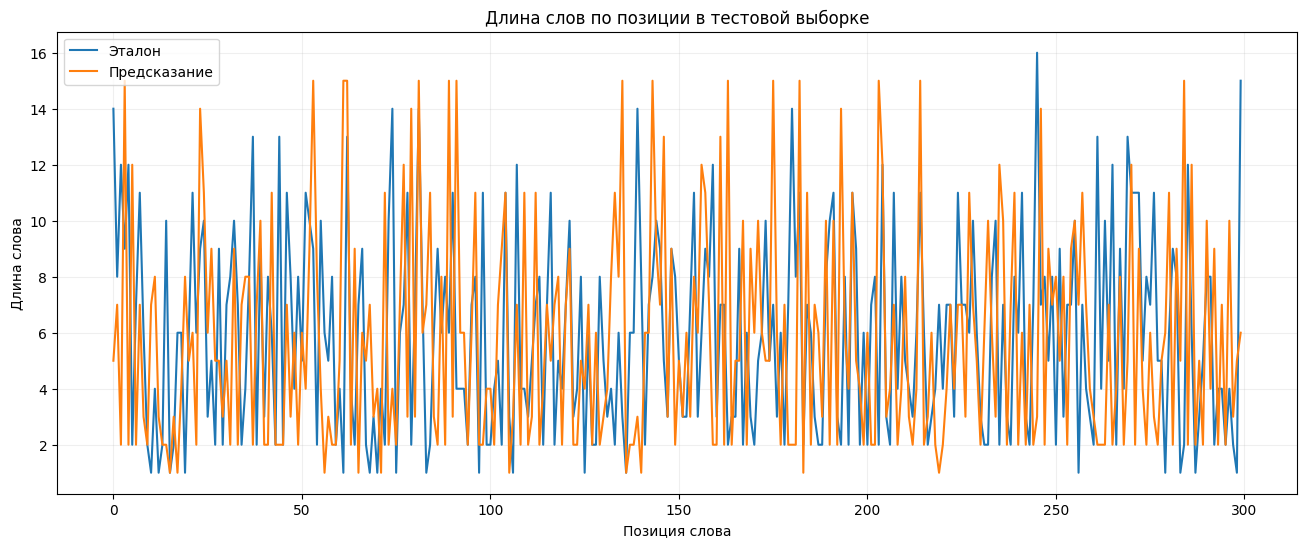

In [33]:
N = min( len(test_text), len(segmented_test_list), 300)

gold_lengths = [
    len(word)
    for word in test_text[:N]
]
pred_lengths = [
    len(word)
    for word in segmented_test_list[:N]
]

plt.figure(figsize=(16, 6))

plt.plot(
    range(N),
    gold_lengths,
    label="Эталон"
)
plt.plot(
    range(N),
    pred_lengths,
    label="Предсказание"
)

plt.xlabel("Позиция слова")
plt.ylabel("Длина слова")
plt.title("Длина слов по позиции в тестовой выборке")

plt.legend()
plt.grid(alpha=0.2)
plt.show()